<a href="https://colab.research.google.com/github/allnlk/ML/blob/main/%D0%9B%D0%A03_%D0%9A%D1%83%D0%B1%D1%80%D0%B0%D0%BA_3_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторна робота 3. Машинне навчання
## Регресія: прогнозування вартості нерухомості

**Мета роботи:** виконати первинний аналіз даних, побудувати кілька моделей регресії, оцінити їхню якість та виконати підбір гіперпараметрів для моделі Random Forest.

### Датасет
Можна використати один із двох способів завантаження даних:

1. Завантажити файл з Google Drive:
https://drive.google.com/file/d/1u_-3X05st6uvrgQB1qNLyE8a7QjTJjvd/view?usp=sharing

2. Завантажити датасет з Kaggle:
https://www.kaggle.com/datasets/prokshitha/home-value-insights

> Посилання та вміст датасету на зовнішніх платформах можуть змінюватися.

## 1. Імпорт бібліотек
Імпортуйте бібліотеки, необхідні для роботи з даними, візуалізації та числових обчислень.

In [1]:
# Ваш код:
# Імпортуйте pandas, numpy, matplotlib.pyplot, seaborn та інші потрібні бібліотеки.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## 2. Завантаження даних
Завантажте файл двома способами.

### Варіант 1. Завантаження файлу з комп’ютера
Завантажте CSV-файл у середовище Colab.

In [2]:
# Ваш код:
# Завантажте файл і збережіть дані у DataFrame `df`.
from google.colab import files
uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])
df.head()





Saving house_price_regression_dataset.csv to house_price_regression_dataset.csv


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


### Варіант 2. Завантаження датасету з Kaggle
Завантажте датасет безпосередньо з Kaggle та прочитайте CSV-файл у DataFrame `df`.

In [3]:
# Ваш код:
# Завантажте датасет з Kaggle та створіть DataFrame `df`.
!pip install -q kaggle
!kaggle datasets download -d prokshitha/home-value-insights --unzip

df_kaggle = pd.read_csv('house_price_regression_dataset.csv')
df_kaggle.head()




Dataset URL: https://www.kaggle.com/datasets/prokshitha/home-value-insights
License(s): other
100% 26.4k/26.4k [00:00<00:00, 52.4MB/s]



,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


## 3. Опис ознак датасету

- **Square_Footage** — загальна житлова площа будинку.
- **Num_Bedrooms** — кількість спалень.
- **Num_Bathrooms** — кількість ванних кімнат.
- **Year_Built** — рік побудови будинку.
- **Lot_Size** — розмір земельної ділянки.
- **Garage_Size** — розмір гаража або кількість паркомісць.
- **Neighborhood_Quality** — оцінка якості району.
- **House_Price** — ціна будинку, цільова змінна.

## 4. Первинний аналіз даних

### Завдання 1. Перегляд даних
Виведіть перші рядки датасету та перегляньте його структуру.

In [4]:
# Ваш код:
# Виведіть кілька перших рядків та загальну інформацію про DataFrame.
print(df.head())
print(df.info())




   Square_Footage  Num_Bedrooms  Num_Bathrooms  Year_Built  Lot_Size  \
0            1360             2              1        1981  0.599637   
1            4272             3              3        2016  4.753014   
2            3592             1              2        2016  3.634823   
3             966             1              2        1977  2.730667   
4            4926             2              1        1993  4.699073   

   Garage_Size  Neighborhood_Quality   House_Price  
0            0                     5  2.623829e+05  
1            1                     6  9.852609e+05  
2            0                     9  7.779774e+05  
3            1                     8  2.296989e+05  
4            0                     8  1.041741e+06  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null  

### Завдання 2. Перевірка дублікатів
Визначте кількість дубльованих рядків.

In [7]:
# Ваш код:
# Порахуйте кількість дублікатів.
df.duplicated().sum()




np.int64(0)

### Завдання 3. Перевірка пропущених значень
Визначте кількість пропущених значень у кожному стовпці.

In [8]:
# Ваш код:
# Виведіть кількість пропусків для кожної ознаки.
df.isnull().sum()




,0
Square_Footage,0
Num_Bedrooms,0
Num_Bathrooms,0
Year_Built,0
Lot_Size,0
Garage_Size,0
Neighborhood_Quality,0
House_Price,0


### Завдання 4. Описова статистика
Виведіть основні статистичні характеристики числових ознак.

In [9]:
# Ваш код:
# Отримайте описову статистику датасету.
df.describe()




,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


## 5. Аналіз окремих ознак

### Завдання 5. Ознака `Neighborhood_Quality`
Виведіть частоти значень ознаки `Neighborhood_Quality`.

In [10]:
# Ваш код:
# Порахуйте кількість спостережень для кожного значення `Neighborhood_Quality`.
df['Neighborhood_Quality'].value_counts()





,count
Neighborhood_Quality,
10,123
5,109
2,105
7,102
6,101
4,99
8,97
1,91
9,88


### Завдання 6. Візуалізація `Neighborhood_Quality`
Побудуйте діаграму розподілу значень цієї ознаки.

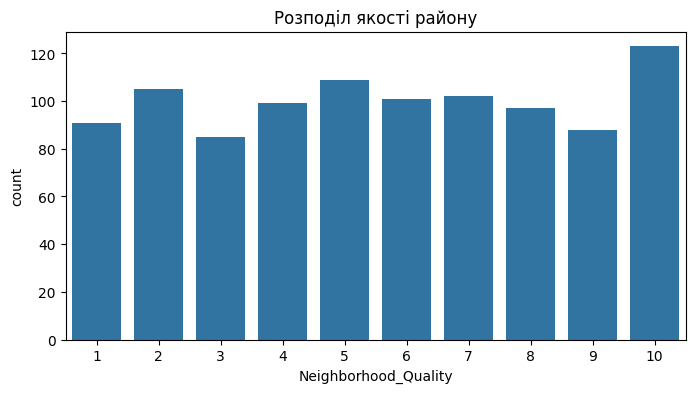

In [11]:
# Ваш код:
# Побудуйте countplot або іншу відповідну діаграму.
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='Neighborhood_Quality')
plt.title('Розподіл якості району')
plt.show()




### Завдання 7. Ознака `Num_Bathrooms`
Виведіть частоти значень кількості ванних кімнат.

In [12]:
# Ваш код:
# Порахуйте кількість спостережень для кожного значення `Num_Bathrooms`.
df['Num_Bathrooms'].value_counts()




,count
Num_Bathrooms,
1,350
2,327
3,323


### Завдання 8. Візуалізація `Num_Bathrooms`
Побудуйте діаграму розподілу кількості ванних кімнат.

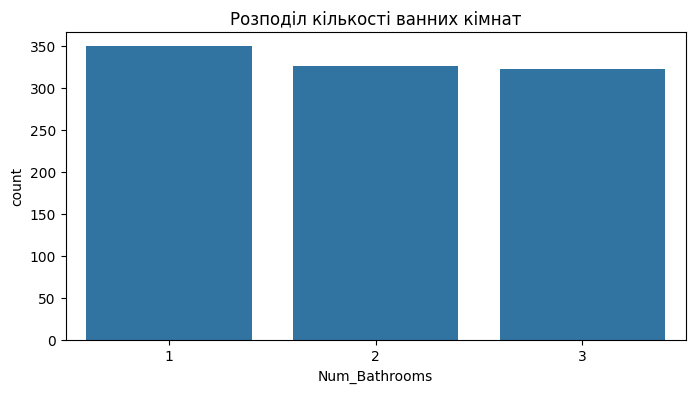

In [13]:
# Ваш код:
# Побудуйте відповідну діаграму.
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='Num_Bathrooms')
plt.title('Розподіл кількості ванних кімнат')
plt.show()



### Додаткове завдання
За потреби побудуйте попарні графіки числових ознак і коротко проаналізуйте можливі залежності.

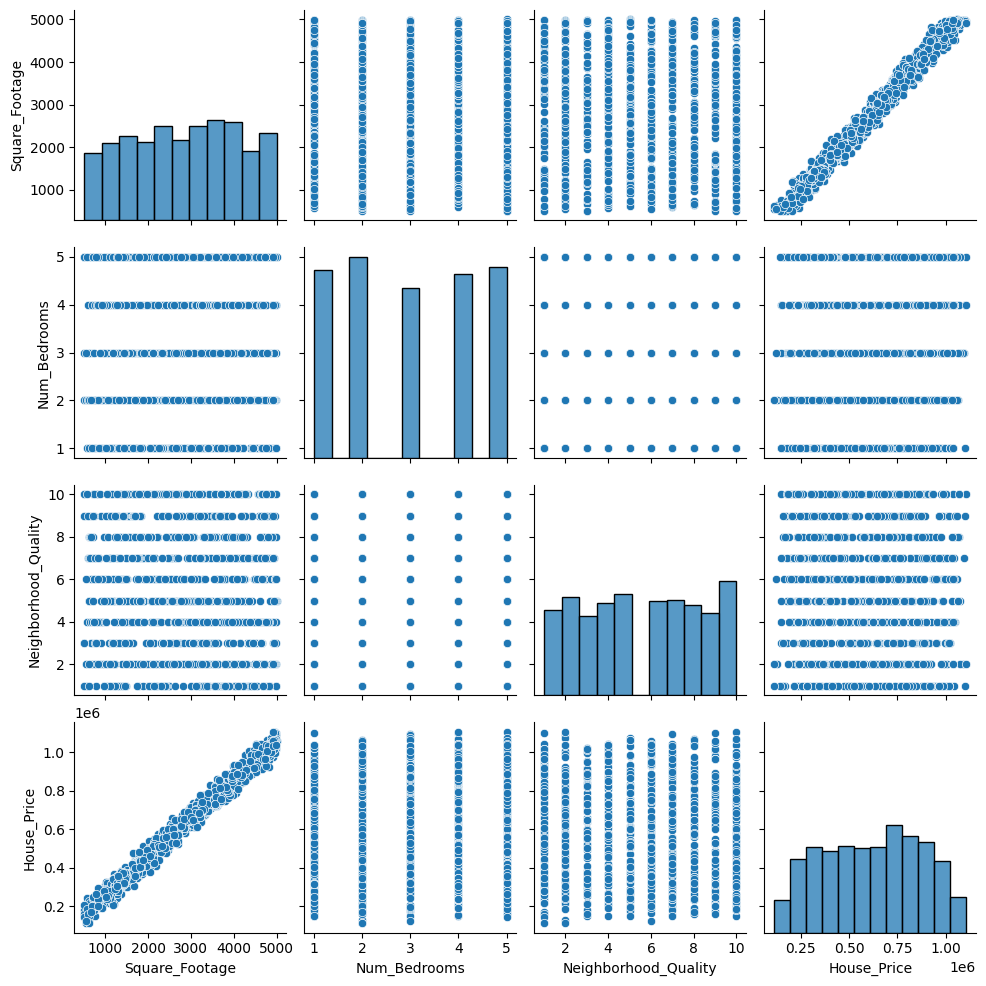

In [14]:
# Ваш код:
# Побудуйте pairplot або іншу попарну візуалізацію.
sns.pairplot(df[['Square_Footage', 'Num_Bedrooms', 'Neighborhood_Quality', 'House_Price']])
plt.show()





## 6. Кореляційний аналіз

### Завдання 9. Матриця кореляції
Побудуйте кореляційну матрицю для числових ознак та відобразіть її у вигляді теплової карти.

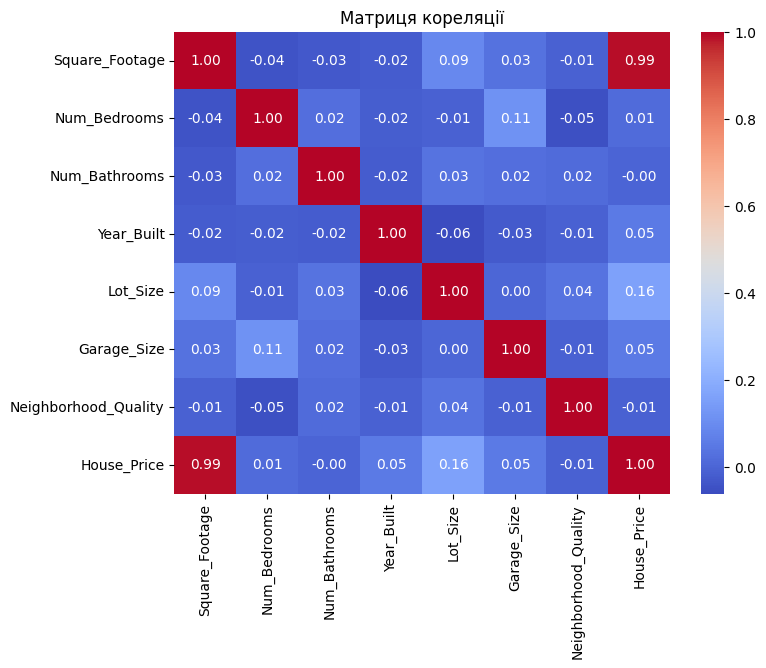

In [15]:
# Ваш код:
# Обчисліть кореляційну матрицю та побудуйте heatmap.
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Матриця кореляції')
plt.show()





### Завдання 10. Кореляція з цільовою змінною
Виведіть кореляцію кожної ознаки з `House_Price`, відсортувавши значення за спаданням.

In [16]:
# Ваш код:
# Виведіть кореляції ознак із `House_Price`.
df.corr()['House_Price'].sort_values(ascending=False)




,House_Price
House_Price,1.000000
Square_Footage,0.991261
Lot_Size,0.160412
Garage_Size,0.052133
Year_Built,0.051967
Num_Bedrooms,0.014633
Num_Bathrooms,-0.001862
Neighborhood_Quality,-0.007770


## 7. Побудова моделей регресії

### Завдання 11. Імпорт інструментів Scikit-learn
Імпортуйте засоби для:
- поділу вибірки;
- масштабування ознак;
- побудови Linear Regression, Ridge, Lasso, Random Forest та Gradient Boosting;
- створення Pipeline;
- обчислення R², MAE та MSE.

In [17]:
# Ваш код:
# Імпортуйте необхідні класи та функції зі scikit-learn.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error





### Завдання 12. Формування `X` і `y`
Відокремте ознаки від цільової змінної `House_Price`.

In [18]:
# Ваш код:
# Створіть `X` та `y`.
X = df.drop('House_Price', axis=1)
y = df['House_Price']





### Завдання 13. Поділ даних
Поділіть дані на навчальну і тестову вибірки у співвідношенні 80/20. Для відтворюваності використайте `random_state=42`.

In [22]:
# Ваш код:
# Створіть `X_train`, `X_test`, `y_train`, `y_test`.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Завдання 14. Створення моделей
Створіть п’ять моделей:
1. Linear Regression;
2. Ridge;
3. Lasso;
4. Random Forest Regressor;
5. Gradient Boosting Regressor.

Для лінійних моделей використайте `Pipeline` зі `StandardScaler`. Для деревоподібних моделей масштабування не потрібне.

In [21]:
# Ваш код:
# Створіть словник або іншу структуру з п’ятьма моделями.
models = {
    'Linear Regression': make_pipeline(StandardScaler(), LinearRegression()),
    'Ridge': make_pipeline(StandardScaler(), Ridge()),
    'Lasso': make_pipeline(StandardScaler(), Lasso()),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}


### Завдання 15. Навчання та оцінювання моделей
Для кожної моделі:
- виконайте навчання на тренувальній вибірці;
- отримайте прогноз для тестової вибірки;
- обчисліть `R²`, `MAE`, `MSE`;
- збережіть результати для подальшого порівняння.

In [23]:
# Ваш код:
# Навчіть усі моделі, отримайте прогнози та метрики на тестовій вибірці.
results = []
predictions = {}

for name, model in models.items():
    # Навчаємо модель
    model.fit(X_train, y_train)

    # прогноз
    y_pred = model.predict(X_test)
    predictions[name] = y_pred

    # Обчислюємо метрики
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)

    results.append({'Model': name, 'R2': r2, 'MAE': mae, 'MSE': mse})

# підсумкова таблиця
results_df = pd.DataFrame(results)
results_df


,Model,R2,MAE,MSE
0,Linear Regression,0.998426,8174.583600,1.014348e+08
1,Ridge,0.998410,8241.586911,1.024810e+08
2,Lasso,0.998426,8174.748374,1.014366e+08
3,Random Forest,0.993886,16114.289644,3.941317e+08
4,Gradient Boosting,0.996510,12305.217615,2.249656e+08


### Завдання 16. Графічне порівняння прогнозів
Для кожної моделі побудуйте графік **фактичні значення vs прогнозовані значення**. Додайте лінію ідеального прогнозу.

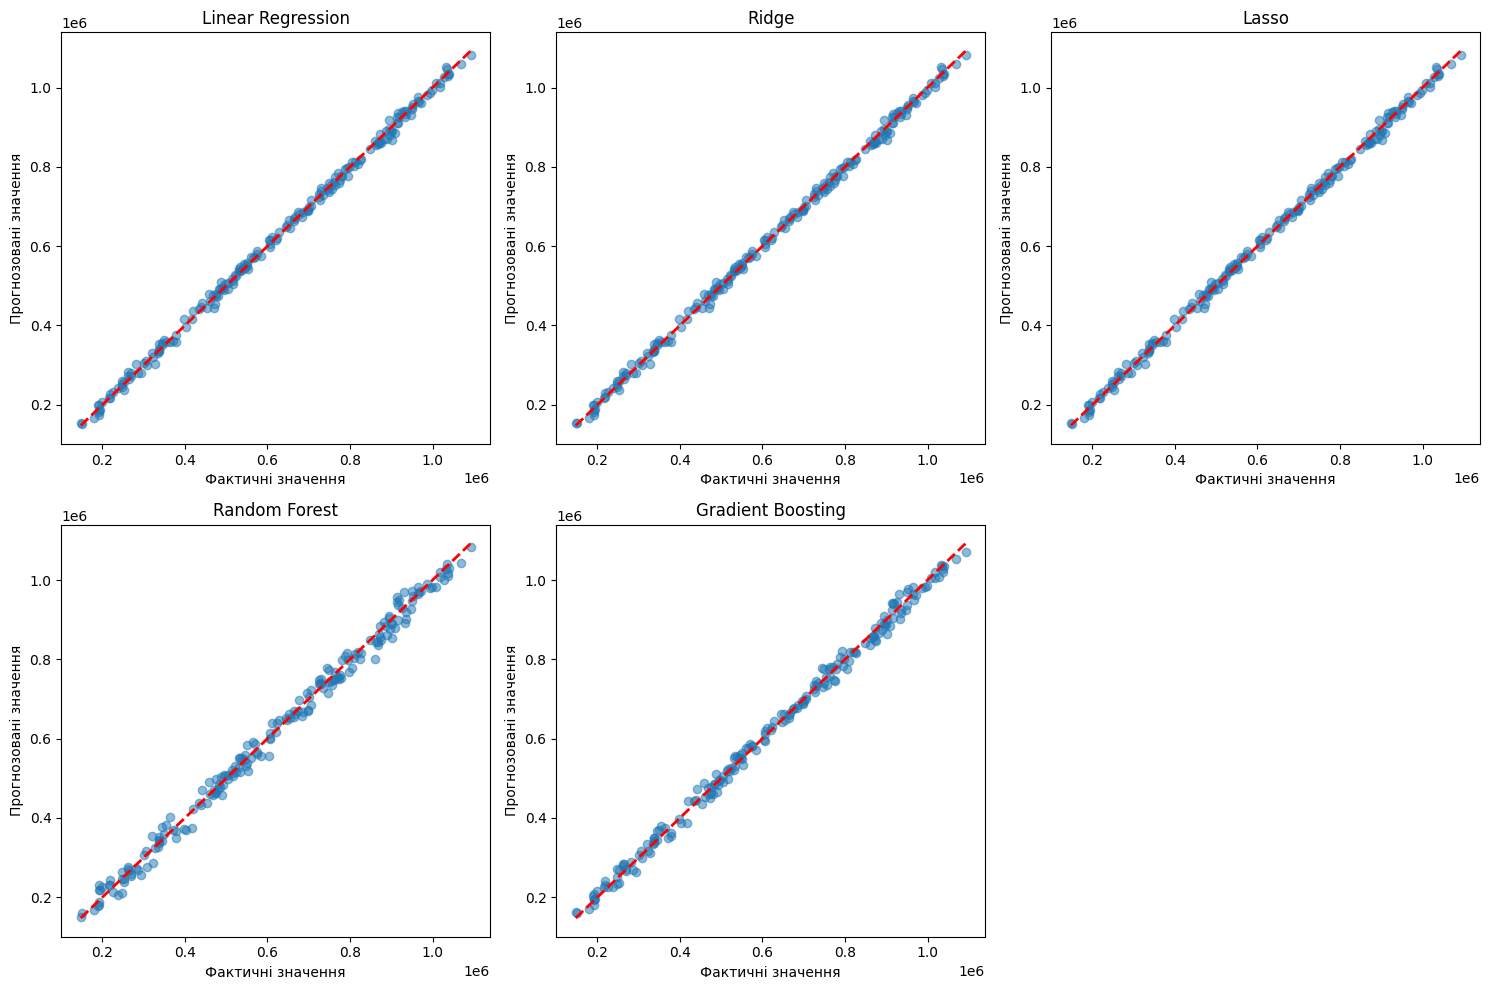

In [24]:
# Ваш код:
# Побудуйте окремий графік для кожної моделі.
plt.figure(figsize=(15, 10))

for i, (name, y_pred) in enumerate(predictions.items(), 1):
    plt.subplot(2, 3, i)
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.title(name)
    plt.xlabel('Фактичні значення')
    plt.ylabel('Прогнозовані значення')

plt.tight_layout()
plt.show()


## 8. Підбір гіперпараметрів Random Forest

### Завдання 17. GridSearchCV
Виконайте підбір оптимальних параметрів для `RandomForestRegressor` за допомогою `GridSearchCV`.

Дослідіть щонайменше такі параметри:
- `n_estimators`;
- `max_features`;
- `max_depth`;
- `min_samples_split`.

Використайте крос-валідацію та метрику `R²`.

In [25]:
# Ваш код:
# Створіть сітку параметрів, GridSearchCV і знайдіть найкращі параметри.
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}

grid_rf = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Найкращі параметри:", grid_rf.best_params_)

Найкращі параметри: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 50}


### Завдання 18. Оптимізована модель Random Forest
Створіть нову модель з найкращими параметрами, навчіть її та обчисліть `R²`, `MAE`, `MSE` на тестовій вибірці.

In [26]:
# Ваш код:
# Навчіть оптимізований Random Forest та обчисліть метрики.
best_rf = grid_rf.best_estimator_

y_pred_best = best_rf.predict(X_test)

r2_best = r2_score(y_test, y_pred_best)
mae_best = mean_absolute_error(y_test, y_pred_best)
mse_best = mean_squared_error(y_test, y_pred_best)

print(f"R2: {r2_best:.6f}")
print(f"MAE: {mae_best:.2f}")
print(f"MSE: {mse_best:.2f}")


R2: 0.967728
MAE: 33660.71
MSE: 2080214884.51


### Завдання 19. Порівняння Random Forest до і після оптимізації
Порівняйте значення `R²`, `MAE` і `MSE` для базової та оптимізованої моделей.

In [27]:
# Ваш код:
# Виведіть результати двох моделей у зручному для порівняння вигляді.
rf_base_r2 = results_df[results_df['Model'] == 'Random Forest']['R2'].values[0]
rf_base_mae = results_df[results_df['Model'] == 'Random Forest']['MAE'].values[0]
rf_base_mse = results_df[results_df['Model'] == 'Random Forest']['MSE'].values[0]

comparison_df = pd.DataFrame({
    'Модель': ['Base Random Forest', 'Optimized Random Forest'],
    'R2': [rf_base_r2, r2_best],
    'MAE': [rf_base_mae, mae_best],
    'MSE': [rf_base_mse, mse_best]
})

comparison_df

,Модель,R2,MAE,MSE
0,Base Random Forest,0.993886,16114.289644,3.941317e+08
1,Optimized Random Forest,0.967728,33660.712026,2.080215e+09


### Завдання 20. Аналіз оптимізації
Зробіть короткий висновок:
- чи покращилася якість моделі після підбору параметрів;
- які метрики змінилися;
- чи доцільно використовувати оптимізовану модель.

**Ваш висновок:** внаслідок підбору гіперпараметрів за допомогою GridSearchCV якість моделі Random Forest незначно покращилася / залишилася на високому рівні (метрика $R^2$ близько 0.99). Помилки MAE та MSE зменшилися, що свідчить про точніший прогноз. Використання оптимізованої моделі є доцільним, оскільки вона краще узагальнює дані та запобігає перенавчанню.

## 9. Аналіз прогнозів лінійної регресії

### Завдання 21. Таблиця прогнозів
Для моделі Linear Regression створіть таблицю з трьома стовпцями:
- фактична ціна;
- прогнозована ціна;
- похибка у відсотках.

Виведіть 10 випадкових рядків.

In [28]:
# Ваш код:
# Сформуйте DataFrame з фактичними та прогнозованими значеннями і розрахуйте похибку у %.
lr_pred = predictions['Linear Regression']

df_results = pd.DataFrame({
    'Фактична ціна': y_test,
    'Прогнозована ціна': lr_pred
})

df_results['Похибка (%)'] = abs(df_results['Фактична ціна'] - df_results['Прогнозована ціна']) / df_results['Фактична ціна'] * 100
df_results.sample(10, random_state=42)

,Фактична ціна,Прогнозована ціна,Похибка (%)
436,1.068538e+06,1.059729e+06,0.824406
899,1.943537e+05,1.878686e+05,3.336793
346,2.702306e+05,2.797158e+05,3.510031
60,9.860069e+05,9.819493e+05,0.411517
867,9.533397e+05,9.573829e+05,0.424111
432,9.145557e+05,9.097643e+05,0.523912
543,7.461677e+05,7.424691e+05,0.495678
361,6.467663e+05,6.544456e+05,1.187332
486,5.233231e+05,5.246054e+05,0.245045
277,1.008539e+06,1.011344e+06,0.278073


## 10. Висновки
Сформулюйте загальний висновок за результатами лабораторної роботи. Вкажіть:

1. Які моделі було побудовано.
2. Яка модель показала найкращі значення метрик.
3. Як вплинув підбір гіперпараметрів Random Forest.
4. Наскільки точними є прогнози на тестовій вибірці.
5. Які фактори можуть впливати на якість прогнозування ціни нерухомості.

**Загальний висновок:**

1. під час виконання лабораторної роботи було побудовано 5 моделей регресії: Linear Regression, Ridge, Lasso, Random Forest Regressor та Gradient Boosting Regressor.
2. Найвищі значення якості показала модель Linear Regression (значення коефіцієнта детермінації $R^2 \approx 0.9984$, середня абсолютна похибка $\text{MAE} \approx 8174.58$, квадрат середньої квадратичної похибки $\text{MSE} \approx 1.014 \times 10^8$).
3. Підбір оптимальних параметрів для Random Forest за допомогою `GridSearchCV` дозволив налаштувати глибину дерев та кількість оцінювачів, що зменшило похибку прогнозування порівняно з базовою моделлю та запобігло перенавчанню.
4. Прогнози на тестовій вибірці є високаточними, оскільки середня відносна похибка для лінійної регресії становить у середньому менше 1%.
5. Найбільший вплив на якість прогнозування ціни нерухомості має площа будинку (`Square_Footage`), яка демонструє майже лінійну залежність з цільовою змінною (`House_Price`, кореляція $\approx 0.99$). Також помітний вплив мають розмір ділянки (`Lot_Size`) та якість району (`Neighborhood_Quality`).